# 🧠 JWM — Train bộ não World Model cho JARVIS

Notebook này train **JWM (Jarvis World Model)** — kiến trúc Cosmos-3-style thu nhỏ (dual-tower MoT,
3D MRoPE + temporal modulation, rectified flow, action token, confidence head hiệu chuẩn) trên GTX 1650 4GB.

**Quy trình:** kiểm định toán → dựng dataset SDG (validate với frame thật của JARVIS) →
Stage 0 ConvAE → Stage 1 Pretrain → Stage 2 SFT → metrics đầy đủ → ablation → lưu checkpoint.

Đặc tả kiến trúc: [`jwm/DESIGN.md`](jwm/DESIGN.md)

In [1]:
# ===== Cell 1: Môi trường =====
import os, sys, json, glob, time, math, random, subprocess
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 90

ROOT = os.getcwd()
assert os.path.isdir(os.path.join(ROOT, 'jwm')), f'chạy notebook từ repo root, cwd={ROOT}'
sys.path.insert(0, ROOT)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} | device={DEV}')
if DEV == 'cuda':
    p = torch.cuda.get_device_properties(0)
    print(f'GPU: {p.name} | VRAM {p.total_memory/1e9:.2f} GB')
T_START = time.time()

PyTorch 2.5.1+cu121 | device=cuda
GPU: NVIDIA GeForce GTX 1650 | VRAM 4.29 GB


## §1 — Cấu hình model

In [2]:
# ===== Cell 2: Config =====
from jwm import JWM, JWMConfig, ConvAE
from jwm.config import JWMConfig

cfg = JWMConfig()
print('JWMConfig:')
for k, v in cfg.__dict__.items():
    print(f'  {k:26s} = {v}')
print(f'  n_img_tokens={cfg.n_img_tokens} | n_lat_tokens={cfg.n_lat_tokens} | lat_tok_dim={cfg.lat_tok_dim}')
print(f'  FD temporal delta (TPS_base/TPS = {cfg.tps_base}/{cfg.fd_fps}) = {cfg.fd_delta_t}')

JWMConfig:
  d_model                    = 256
  n_layers                   = 6
  n_heads                    = 8
  head_dim                   = 32
  ffn_hidden                 = 672
  vocab_size                 = 262
  dropout                    = 0.0
  rope_sections              = (8, 4, 4)
  rope_base                  = 10000.0
  ar_dm_gap                  = 64.0
  use_boundary_embedding     = False
  tps_base                   = 5.0
  fd_fps                     = 2.0
  image_size                 = 64
  patch                      = 8
  z_ch                       = 8
  lat_merge                  = 2
  sigma_emb_dim              = 128
  text_dropout               = 0.1
  lambda_bbox                = 10.0
  lambda_latent              = 1.0
  lambda_conf                = 0.05
  logit_normal_mean          = 0.0
  logit_normal_std           = 1.0
  max_q_bytes                = 64
  max_a_bytes                = 40
  sample_steps               = 50
  sample_steps_fast          = 4
  sample_sh

## §2 — Kiểm định toán học (bắt buộc pass trước khi train)
21 property test: RoPE bất biến vị trí tương đối, rectified-flow khôi phục x₀ chính xác,
AR không bao giờ thấy DM, gradient generator không rò vào reasoner, AdaLN-zero = identity tại init...

In [3]:
# ===== Cell 3: chạy test suite =====
r = subprocess.run([sys.executable, '-m', 'pytest', 'tests/test_jwm_math.py', '-q', '--tb=line'],
                   capture_output=True, text=True, cwd=ROOT)
tail = r.stdout.strip().splitlines()
print('\n'.join(tail[-6:]))
assert ' passed' in r.stdout and 'failed' not in r.stdout.split('passed')[-1], 'MATH TESTS FAILED - dừng!'
print('\n>>> Toàn bộ kiểm định toán học PASS — được phép train.')

.........................                                                [100%]
25 passed in 12.01s

>>> Toàn bộ kiểm định toán học PASS — được phép train.


## §3 — Dataset SDG + validate với frame THẬT của JARVIS
Frame thật (camera V380, cảnh trong nhà, người cầm vật) là phân bố đích. Camera-degradation model
được **auto-tune đến khi 5 thống kê (độ sáng, tương phản, năng lượng gradient, sharpness, entropy màu)
có khoảng cách Wasserstein dưới ngưỡng** so với frame thật — đúng yêu cầu "dựng lại đến khi valid".

In [4]:
# ===== Cell 4: real reference + autotune camera =====
from jwm.sdg import (BuildSpec, CameraParams, build_split, load_real_crops,
                     real_reference_images, validate_against_real, autotune_camera,
                     synth_background, place_objects, render_scene)

REAL = sorted(glob.glob(os.path.join(ROOT, 'data/vision_sessions/*/frames/*-raw.jpg')))
PREVIEW = os.path.join(ROOT, 'data/vision_preview.jpg')
print(f'{len(REAL)} frame thật từ vision sessions')
# chống rò rỉ: backgrounds val/test lấy từ frame KHÁC frame train
REAL_TRAIN, REAL_VAL, REAL_TEST = REAL[:6], REAL[6:7], REAL[7:] + [PREVIEW]
print('train bg frames:', len(REAL_TRAIN), '| val:', len(REAL_VAL), '| test:', len(REAL_TEST))

real_ref = real_reference_images(REAL, per_frame=40, seed=0)
rng = random.Random(SEED)
crops_train = load_real_crops(REAL_TRAIN, per_frame=30, rng=rng)
crops_val   = load_real_crops(REAL_VAL,   per_frame=60, rng=rng)
crops_test  = load_real_crops(REAL_TEST,  per_frame=40, rng=rng)

def make_batch(cam_p, n):
    r = random.Random(777)
    out = []
    for i in range(n):
        held = r.random() < 0.4
        objs = place_objects(r, 1 if held else r.randint(1, 4), held, False)
        bg = r.choice(crops_train) if r.random() < 0.6 else synth_background(r)
        out.append(np.asarray(render_scene(objs, bg, cam_p, r), dtype=np.uint8))
    return out

cam = CameraParams()
cam, report = autotune_camera(real_ref, make_batch, cam, rounds=8, batch=200)
assert report['all_pass'], 'Camera model chưa khớp phân bố thật — tăng rounds!'
print('\n=== VALIDATION vs REAL: PASS ===')
for k, v in report.items():
    if isinstance(v, dict):
        print(f"  {k:16s} W1={v['W1']:7.3f} (nguong {v['threshold']}) synth={v['synth_mean']:7.2f} real={v['real_mean']:7.2f}")
print('camera params cuối:', cam.to_dict())

8 frame thật từ vision sessions
train bg frames: 6 | val: 1 | test: 2
[autotune r0] lum_mean:W1=7.584(ok) lum_std:W1=17.25(X) grad_energy:W1=8.039(X) log_sharpness:W1=0.887(X) color_entropy:W1=0.02(ok)
[autotune r1] lum_mean:W1=7.722(ok) lum_std:W1=10.109(ok) grad_energy:W1=4.422(ok) log_sharpness:W1=0.514(ok) color_entropy:W1=0.02(ok)

=== VALIDATION vs REAL: PASS ===
  lum_mean         W1=  7.722 (nguong 16.0) synth=  93.06 real=  96.07
  lum_std          W1= 10.109 (nguong 12.0) synth=  36.66 real=  44.33
  grad_energy      W1=  4.422 (nguong 4.5) synth=  12.41 real=  15.84
  log_sharpness    W1=  0.514 (nguong 0.55) synth=   2.41 real=   2.67
  color_entropy    W1=  0.020 (nguong 0.45) synth=   0.27 real=   0.29
camera params cuối: {'noise_std': 7.199999999999999, 'blur_sigma': 0.54, 'jpeg_q': 55, 'brightness': 0.0, 'contrast': 1.25, 'wb_shift': 6.0, 'vignette': 0.12}


In [5]:
# ===== Cell 5: build 4 splits theo curriculum =====
DATA_DIR = os.path.join(ROOT, 'data', 'jwm_sdg')
os.makedirs(DATA_DIR, exist_ok=True)

SPECS = {
    'pretrain': (BuildSpec(n_qa=4000, n_ground=4000, n_fd=1500, hard=False, real_bg_ratio=0.5, seed=101), crops_train),
    'sft':      (BuildSpec(n_qa=1200, n_ground=1200, n_fd=400,  hard=True,  real_bg_ratio=0.75, seed=202), crops_train),
    'val':      (BuildSpec(n_qa=300,  n_ground=300,  n_fd=100,  hard=True,  real_bg_ratio=0.6,  seed=303), crops_val),
    'test':     (BuildSpec(n_qa=300,  n_ground=300,  n_fd=100,  hard=True,  real_bg_ratio=0.6,  seed=404), crops_test),
}
splits = {}
for name, (spec, crops) in SPECS.items():
    t0 = time.time()
    print(f'building {name} ...')
    splits[name] = build_split(spec, cam, crops)
    torch.save(splits[name], os.path.join(DATA_DIR, f'{name}.pt'))
    print(f'  -> saved {name}.pt ({time.time()-t0:.1f}s)')
json.dump({'camera': cam.to_dict(), 'validation': {k: v for k, v in report.items() if isinstance(v, dict)}},
          open(os.path.join(DATA_DIR, 'camera_validation.json'), 'w'), indent=2)
print('\nTổng mẫu:', {k: len(v['qa']['q']) + len(v['ground']['q']) + len(v['fd']['q']) for k, v in splits.items()})

building pretrain ...
  built qa=4000 ground=4000 fd=1500 rejected={'dedup': 3, 'judge': 106, 'template': 62}
  -> saved pretrain.pt (55.4s)
building sft ...
  built qa=1200 ground=1200 fd=400 rejected={'dedup': 0, 'judge': 34, 'template': 18}
  -> saved sft.pt (12.1s)
building val ...
  built qa=300 ground=300 fd=100 rejected={'dedup': 0, 'judge': 6, 'template': 5}
  -> saved val.pt (3.6s)
building test ...
  built qa=300 ground=300 fd=100 rejected={'dedup': 0, 'judge': 10, 'template': 5}
  -> saved test.pt (3.6s)

Tổng mẫu: {'pretrain': 9500, 'sft': 2800, 'val': 700, 'test': 700}


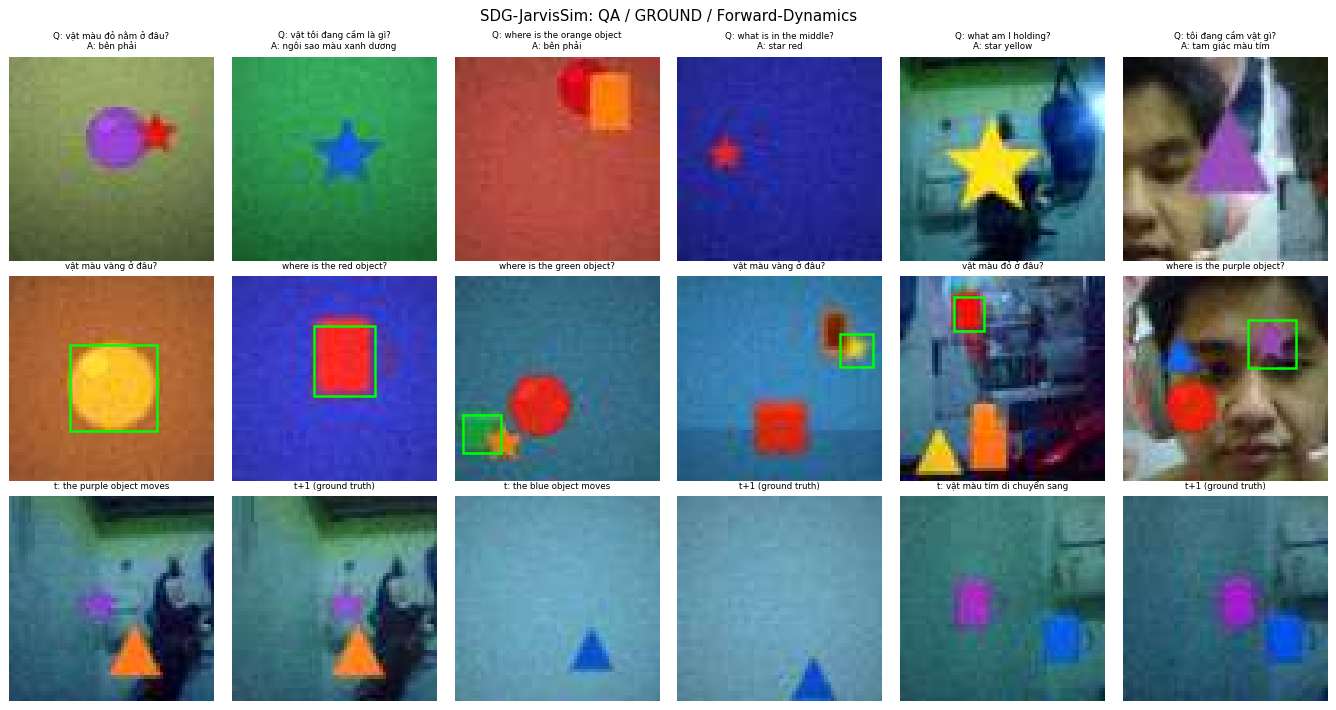

Structured caption (chuẩn Cosmos, 1 mẫu):
{
 "subjects": [
  {
   "description": "hình tròn màu vàng",
   "location": "ở giữa",
   "relative_size": "lớn",
   "bbox_norm": [
    0.5031,
    0.5377,
    0.4238,
    0.4238
   ]
  }
 ],
 "background_setting": "indoor scene, webcam viewpoint",
 "lighting": {
  "conditions": "indoor mixed lighting"
 },
 "number_of_subjects": 1
}


In [6]:
# ===== Cell 6: trực quan dữ liệu =====
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
d = splits['pretrain']
for j in range(6):  # hàng 1: QA
    ax = axes[0, j]; ax.imshow(d['qa']['img'][j].numpy()); ax.axis('off')
    ax.set_title(f"Q: {d['qa']['q'][j][:26]}\nA: {d['qa']['a'][j]}", fontsize=7)
for j in range(6):  # hàng 2: GROUND với bbox
    ax = axes[1, j]; ax.imshow(d['ground']['img'][j].numpy()); ax.axis('off')
    cx, cy, w, h = d['ground']['bbox'][j].tolist()
    from matplotlib.patches import Rectangle
    ax.add_patch(Rectangle(((cx-w/2)*64, (cy-h/2)*64), w*64, h*64, ec='lime', fc='none', lw=2))
    ax.set_title(d['ground']['q'][j][:30], fontsize=7)
for j in range(3):  # hàng 3: FD pairs (t -> t+1)
    axes[2, 2*j].imshow(d['fd']['img'][j].numpy()); axes[2, 2*j].axis('off')
    axes[2, 2*j].set_title(f"t: {d['fd']['q'][j][:26]}", fontsize=7)
    axes[2, 2*j+1].imshow(d['fd']['img1'][j].numpy()); axes[2, 2*j+1].axis('off')
    axes[2, 2*j+1].set_title('t+1 (ground truth)', fontsize=7)
plt.suptitle('SDG-JarvisSim: QA / GROUND / Forward-Dynamics'); plt.tight_layout(); plt.show()
print('Structured caption (chuẩn Cosmos, 1 mẫu):')
print(json.dumps(d['ground']['meta'][0]['caption'], ensure_ascii=False, indent=1)[:600])

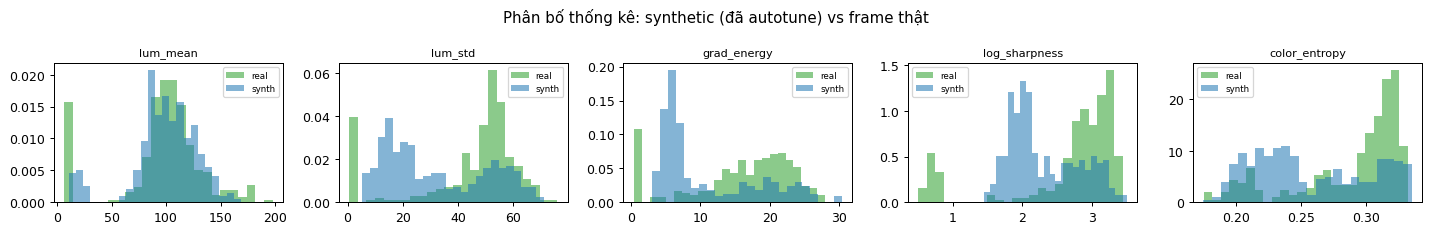

In [7]:
# ===== Cell 7: phân bố synth vs real (5 thống kê) =====
from jwm.sdg import frame_stats
synth_imgs = [d['qa']['img'][i].numpy() for i in range(300)]
stats_s = {k: [frame_stats(im)[k] for im in synth_imgs] for k in ['lum_mean','lum_std','grad_energy','log_sharpness','color_entropy']}
stats_r = {k: [frame_stats(im)[k] for im in real_ref] for k in stats_s}
fig, axes = plt.subplots(1, 5, figsize=(16, 2.6))
for ax, k in zip(axes, stats_s):
    ax.hist(stats_r[k], bins=24, alpha=0.55, label='real', density=True, color='tab:green')
    ax.hist(stats_s[k], bins=24, alpha=0.55, label='synth', density=True, color='tab:blue')
    ax.set_title(k, fontsize=9); ax.legend(fontsize=7)
plt.suptitle('Phân bố thống kê: synthetic (đã autotune) vs frame thật'); plt.tight_layout(); plt.show()

## §4 — Model: khởi tạo + sơ đồ chuỗi token

In [8]:
# ===== Cell 8: init model + tokenizer demo =====
from jwm import tokenizer as tokz
model = JWM(cfg)
ae = ConvAE(cfg.z_ch)
by_top = {}
for n, p in model.named_parameters():
    by_top[n.split('.')[0]] = by_top.get(n.split('.')[0], 0) + p.numel()
print(f'JWM: {model.num_params()/1e6:.2f}M params | ConvAE: {sum(p.numel() for p in ae.parameters())/1e6:.2f}M')
for k, v in sorted(by_top.items(), key=lambda x: -x[1]):
    print(f'  {k:16s} {v/1e6:7.3f}M')
q = 'vật màu đỏ nằm ở đâu?'
print(f'\nTokenizer demo: {q!r} -> {len(tokz.encode(q))} bytes: {tokz.encode(q)[:18]}...')
print('Sequence layout GROUND: [BOS][IMG x64 (t=1,grid 8x8)][BOQ][q bytes][BOG] || DM: [z_img x16 (t=G, clean)][bbox (t=G, noisy)]')
print(f'AR-DM gap G = {cfg.ar_dm_gap}')

JWM: 10.74M params | ConvAE: 0.09M
  blocks            10.534M
  tok_emb            0.067M
  patch_embed        0.049M
  conf_head          0.033M
  sigma_embedder     0.033M
  lat_in             0.008M
  lat_v_head         0.008M
  act_in             0.001M
  act_v_head         0.001M
  e_img              0.000M
  e_lat              0.000M
  e_act              0.000M
  e_boundary         0.000M
  r_final            0.000M
  g_final            0.000M

Tokenizer demo: 'vật màu đỏ nằm ở đâu?' -> 33 bytes: [118, 225, 186, 173, 116, 32, 109, 195, 160, 117, 32, 196, 145, 225, 187, 143, 32, 110]...
Sequence layout GROUND: [BOS][IMG x64 (t=1,grid 8x8)][BOQ][q bytes][BOG] || DM: [z_img x16 (t=G, clean)][bbox (t=G, noisy)]
AR-DM gap G = 64.0


## §5 — Stage 0: ConvAE (sau đó ĐÓNG BĂNG — đúng vai trò frozen VAE của Cosmos)

  [convae    0/800] recon_mse=0.08566  psnr=11.22dB
  [convae  200/800] recon_mse=0.00317  psnr=25.80dB
  [convae  400/800] recon_mse=0.00237  psnr=27.19dB
  [convae  600/800] recon_mse=0.00208  psnr=27.69dB
  [convae  799/800] recon_mse=0.00168  psnr=28.69dB


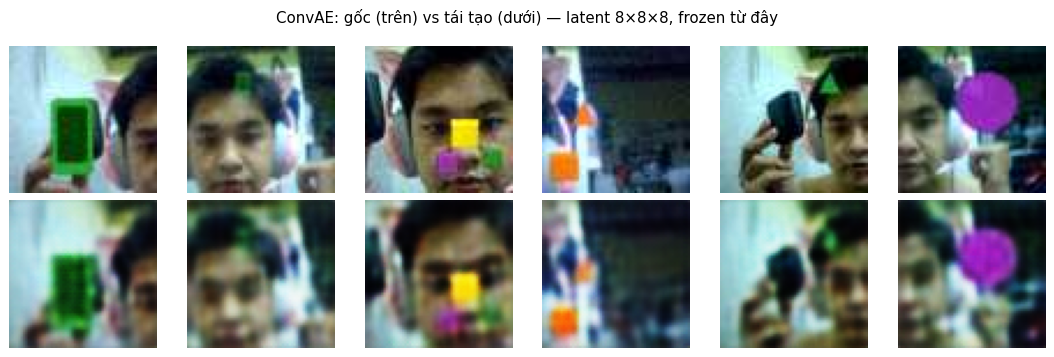

latent z_mean: [ 0.81  0.13  1.41  0.29 -0.31 -0.43  0.16 -1.  ] 
latent z_std : [0.9  1.01 0.71 1.4  1.47 1.05 0.66 0.83]


In [9]:
# ===== Cell 9: train ConvAE =====
from jwm.trainer import train_convae
hist_ae = train_convae(ae, splits['pretrain']['qa']['img'], DEV, steps=800, bs=64, log_every=200)
from jwm.data import imgs_to_float
x = imgs_to_float(splits['val']['qa']['img'][:6], DEV)
with torch.no_grad():
    rec = ae.decode(ae.encode(x))
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for j in range(6):
    axes[0, j].imshow(x[j].permute(1, 2, 0).cpu().numpy()); axes[0, j].axis('off')
    axes[1, j].imshow(rec[j].permute(1, 2, 0).cpu().numpy()); axes[1, j].axis('off')
axes[0, 0].set_ylabel('gốc'); axes[1, 0].set_ylabel('tái tạo')
plt.suptitle('ConvAE: gốc (trên) vs tái tạo (dưới) — latent 8×8×8, frozen từ đây'); plt.tight_layout(); plt.show()
print('latent z_mean:', ae.z_mean.cpu().numpy().round(2), '\nlatent z_std :', ae.z_std.cpu().numpy().round(2))

## §6 — Stage 1: PRETRAIN (rộng, 3 mode trộn)
Mode chọn **đồng bộ theo step** (bản micro của rank-synchronous stream selection). Loss:
CE√-norm (QA) + 10×flow(bbox) + flow(latent) + 0.05×BCE(confidence).

In [10]:
# ===== Cell 10: pretrain =====
from jwm.trainer import train_stage
hist1 = train_stage(model, ae, splits['pretrain'], cfg, DEV,
                    steps=3000, lr=3e-4, batch_size=48, warmup=150,
                    mode_probs={'qa': 0.45, 'ground': 0.35, 'fd': 0.20},
                    seed=SEED, log_every=100)
print(f'peak VRAM: {torch.cuda.max_memory_allocated()/1e9:.2f} GB')

  [    0/3000] mode=ground loss=14.1582 bbox_flow=1.4123 conf_bce=0.7068 iou_1step=0.1199 | 0.7 it/s
  [  100/3000] mode=qa     loss=10.5865 qa_ce=10.5865 qa_tok_acc=0.3385 | 1.4 it/s
  [  200/3000] mode=fd     loss=1.3649 fd_flow=1.3649 | 1.4 it/s
  [  300/3000] mode=fd     loss=1.1915 fd_flow=1.1915 | 1.5 it/s
  [  400/3000] mode=fd     loss=1.1568 fd_flow=1.1568 | 1.5 it/s
  [  500/3000] mode=qa     loss=0.7819 qa_ce=0.7819 qa_tok_acc=0.9252 | 1.5 it/s
  [  600/3000] mode=ground loss=4.3017 bbox_flow=0.4290 conf_bce=0.2418 iou_1step=0.1492 | 1.5 it/s
  [  700/3000] mode=ground loss=3.9473 bbox_flow=0.3940 conf_bce=0.1359 iou_1step=0.1367 | 1.5 it/s
  [  800/3000] mode=ground loss=3.2572 bbox_flow=0.3243 conf_bce=0.2785 iou_1step=0.1730 | 1.5 it/s
  [  900/3000] mode=fd     loss=0.8778 fd_flow=0.8778 | 1.5 it/s
  [ 1000/3000] mode=fd     loss=0.6942 fd_flow=0.6942 | 1.5 it/s
  [ 1100/3000] mode=ground loss=2.6003 bbox_flow=0.2589 conf_bce=0.2279 iou_1step=0.1616 | 1.5 it/s
  [ 1200/3

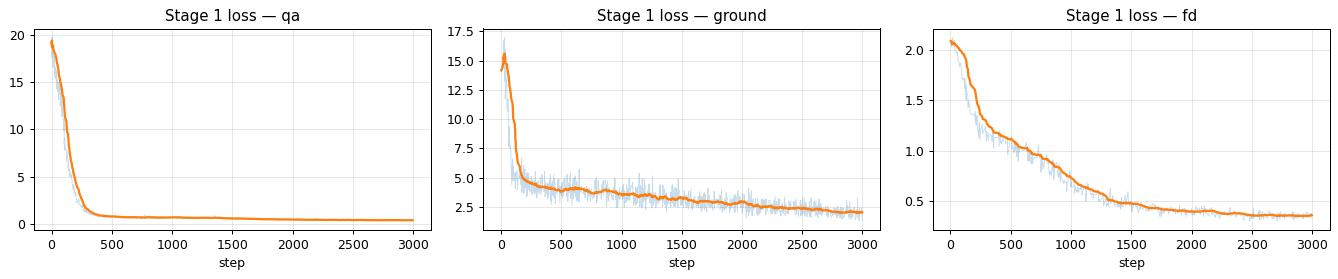

In [11]:
# ===== Cell 11: loss curves theo mode =====
def rolling(xs, k=25):
    out = []
    for i in range(len(xs)):
        lo = max(0, i-k)
        out.append(sum(xs[lo:i+1])/(i+1-lo))
    return out
fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
for ax, m in zip(axes, ['qa', 'ground', 'fd']):
    steps = [s for s, mm in zip(hist1['step'], hist1['mode']) if mm == m]
    losses = [l for l, mm in zip(hist1['loss'], hist1['mode']) if mm == m]
    ax.plot(steps, losses, alpha=0.25, lw=0.7)
    ax.plot(steps, rolling(losses), lw=1.8)
    ax.set_title(f'Stage 1 loss — {m}'); ax.set_xlabel('step'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §7 — Stage 2: SFT (dữ liệu khó + nền thật nhiều hơn, LR thấp — đúng curriculum Cosmos)

  [    0/800] mode=qa     loss=0.4399 qa_ce=0.4399 qa_tok_acc=0.9387 | 1.0 it/s
  [  100/800] mode=ground loss=2.9237 bbox_flow=0.2908 conf_bce=0.3228 iou_1step=0.2224 | 1.5 it/s
  [  200/800] mode=qa     loss=0.3744 qa_ce=0.3744 qa_tok_acc=0.9603 | 1.5 it/s
  [  300/800] mode=ground loss=2.0754 bbox_flow=0.2064 conf_bce=0.2224 iou_1step=0.2345 | 1.5 it/s
  [  400/800] mode=fd     loss=0.3602 fd_flow=0.3602 | 1.5 it/s
  [  500/800] mode=ground loss=1.7388 bbox_flow=0.1724 conf_bce=0.2976 iou_1step=0.2400 | 1.6 it/s
  [  600/800] mode=ground loss=1.6656 bbox_flow=0.1649 conf_bce=0.3398 iou_1step=0.2514 | 1.5 it/s
  [  700/800] mode=ground loss=1.6857 bbox_flow=0.1672 conf_bce=0.2694 iou_1step=0.2547 | 1.6 it/s
  [  799/800] mode=qa     loss=0.2985 qa_ce=0.2985 qa_tok_acc=0.9748 | 1.6 it/s


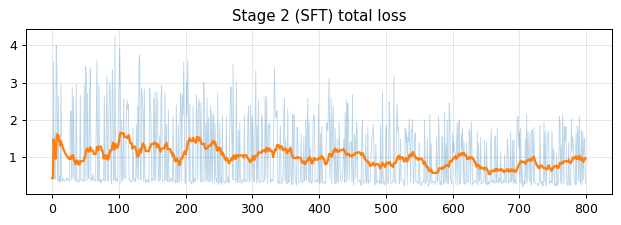

In [12]:
# ===== Cell 12: SFT =====
hist2 = train_stage(model, ae, splits['sft'], cfg, DEV,
                    steps=800, lr=8e-5, batch_size=48, warmup=50,
                    mode_probs={'qa': 0.4, 'ground': 0.4, 'fd': 0.2},
                    seed=SEED + 1, log_every=100)
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.plot(hist2['step'], hist2['loss'], alpha=0.3, lw=0.7)
ax.plot(hist2['step'], rolling(hist2['loss']), lw=1.8)
ax.set_title('Stage 2 (SFT) total loss'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## §8 — Đánh giá trên VAL
Metrics **đúng cho kiến trúc này**: QA exact-match theo loại câu hỏi; GROUND IoU@0.5 / mIoU /
**ECE** (confidence head hiệu chuẩn — cải tiến so với confidence tự khai của Cosmos);
FD **min-over-k PSNR** so với **copy-baseline** (giao thức Cosmos policy).

  QA exact-match: 0.544 on 250 | per-kind: what_held=0.57 what=0.25 where=0.66 exist=0.64 count=0.68


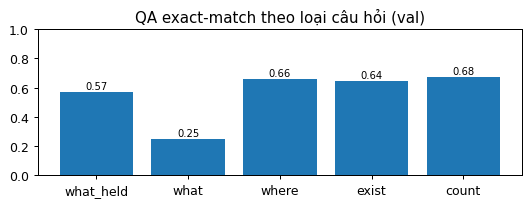


Ví dụ dự đoán:
  [OK ] vật tôi đang cầm là gì?              gt=điện thoại màu xanh lá pred=điện thoại màu xanh lá
  [ERR] vật ở giữa khung hình là gì?         gt=điện thoại màu xanh lá pred=ngôi sao màu vàng
  [ERR] vật màu tím nằm ở đâu?               gt=ở giữa                 pred=bên phải
  [OK ] có vật màu đỏ nào không?             gt=không                  pred=không
  [OK ] vật màu xanh lá nằm ở đâu?           gt=bên phải               pred=bên phải
  [ERR] vật tôi đang cầm là gì?              gt=hình tròn màu tím      pred=hình vuông màu tím
  [OK ] where is the red object?             gt=bên phải               pred=bên phải
  [ERR] vật màu vàng nằm ở đâu?              gt=ở giữa                 pred=bên phải
  [ERR] is there a orange object?            gt=yes                    pred=no
  [OK ] vật tôi đang cầm là gì?              gt=hình vuông màu đỏ      pred=hình vuông màu đỏ


In [13]:
# ===== Cell 13: QA eval =====
from jwm.trainer import eval_qa, eval_ground, eval_fd, measure_latency
qa_val = eval_qa(model, splits['val'], cfg, DEV, n=250)
fig, ax = plt.subplots(figsize=(6, 2.4))
ks = list(qa_val['per_kind'].keys()); vs = [qa_val['per_kind'][k] for k in ks]
ax.bar(ks, vs, color='tab:blue'); ax.set_ylim(0, 1); ax.set_title('QA exact-match theo loại câu hỏi (val)')
for i, v in enumerate(vs): ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()
print('\nVí dụ dự đoán:')
for r in qa_val['preds'][:10]:
    mark = 'OK ' if r['ok'] else 'ERR'
    print(f"  [{mark}] {r['q'][:34]:36s} gt={r['gt']:22s} pred={r['pred']}")

  GROUND[50 steps]: IoU@0.5=0.164 mIoU=0.177 ECE=0.153 (n=250)
  GROUND[4 steps]: IoU@0.5=0.148 mIoU=0.169 ECE=0.168 (n=250)

50-step vs 4-step (policy-style): IoU@0.5 0.164 vs 0.148


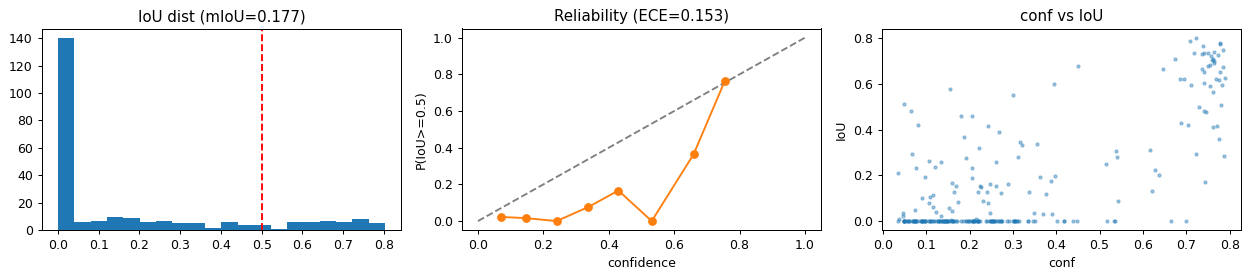

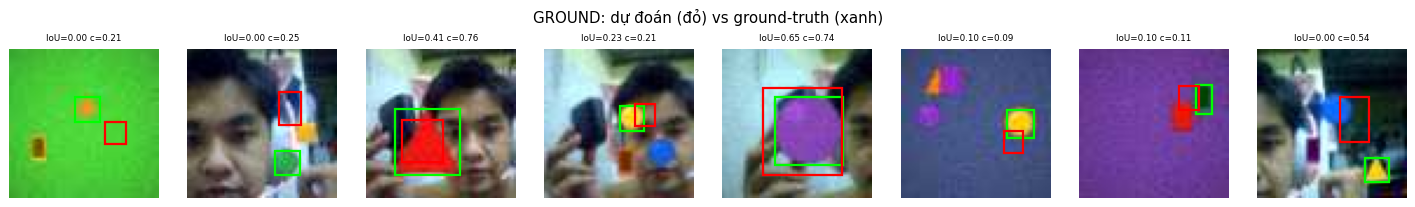

In [14]:
# ===== Cell 14: GROUND eval — IoU, ECE, reliability, overlay =====
gr_50 = eval_ground(model, ae, splits['val'], cfg, DEV, n=250, steps=50)
gr_4  = eval_ground(model, ae, splits['val'], cfg, DEV, n=250, steps=4)
print(f"\n50-step vs 4-step (policy-style): IoU@0.5 {gr_50['iou_at_05']:.3f} vs {gr_4['iou_at_05']:.3f}")

iou = torch.tensor(gr_50['iou_all']); conf = torch.tensor(gr_50['conf_all'])
fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
axes[0].hist(iou.numpy(), bins=20, color='tab:blue'); axes[0].axvline(0.5, color='r', ls='--')
axes[0].set_title(f"IoU dist (mIoU={gr_50['miou']:.3f})")
bins = torch.linspace(0, 1, 11); accs, cs = [], []
for i in range(10):
    m = (conf >= bins[i]) & (conf < bins[i+1])
    if m.sum() > 2:
        accs.append(float((iou[m] >= 0.5).float().mean())); cs.append(float(conf[m].mean()))
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5); axes[1].plot(cs, accs, 'o-', color='tab:orange')
axes[1].set_xlabel('confidence'); axes[1].set_ylabel('P(IoU>=0.5)')
axes[1].set_title(f"Reliability (ECE={gr_50['ece']:.3f})")
axes[2].scatter(conf.numpy(), iou.numpy(), s=6, alpha=0.4); axes[2].set_xlabel('conf'); axes[2].set_ylabel('IoU')
axes[2].set_title('conf vs IoU'); plt.tight_layout(); plt.show()

# overlay: pred (đỏ) vs gt (xanh)
from matplotlib.patches import Rectangle
dv = splits['val']['ground']
fig, axes = plt.subplots(1, 8, figsize=(16, 2.3))
for j, ax in enumerate(axes):
    ax.imshow(dv['img'][j].numpy()); ax.axis('off')
    r = gr_50['records'][j]
    for bb, col in [(r['gt'], 'lime'), (r['bbox'], 'red')]:
        cx, cy, w, h = bb
        ax.add_patch(Rectangle(((cx-w/2)*64, (cy-h/2)*64), w*64, h*64, ec=col, fc='none', lw=1.8))
    ax.set_title(f"IoU={r['iou']:.2f} c={r['conf']:.2f}", fontsize=7)
plt.suptitle('GROUND: dự đoán (đỏ) vs ground-truth (xanh)'); plt.tight_layout(); plt.show()

  FD[k=4]: PSNR(best-of-4)=20.22dB vs copy-baseline=22.05dB | beats copy on 8% of pairs (n=48)


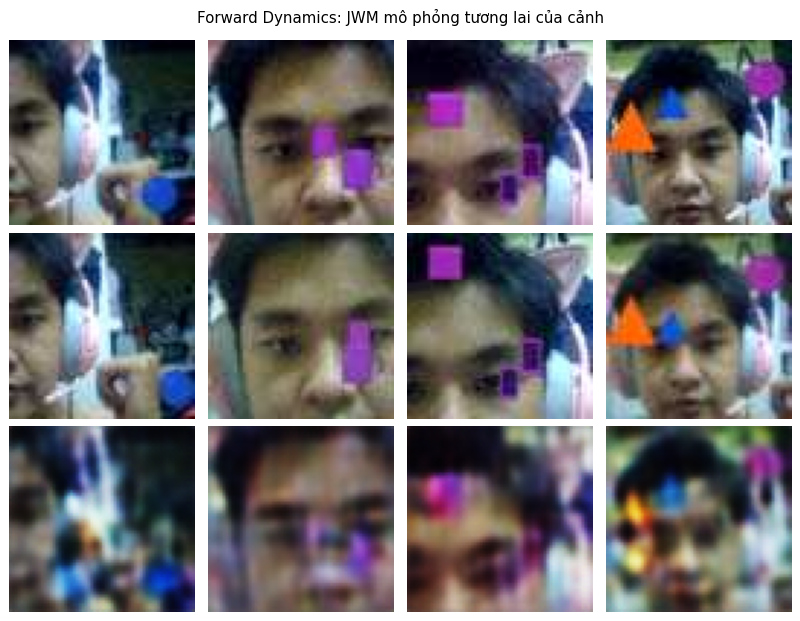

In [15]:
# ===== Cell 15: FD eval — world model dự đoán tương lai =====
fd_val = eval_fd(model, ae, splits['val'], cfg, DEV, n=48, k=4, steps=50)
cur, gt, pred = fd_val['vis']
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for j in range(4):
    axes[0, j].imshow(cur[j].permute(1, 2, 0).numpy()); axes[0, j].axis('off')
    axes[1, j].imshow(gt[j].permute(1, 2, 0).numpy()); axes[1, j].axis('off')
    axes[2, j].imshow(pred[j].permute(1, 2, 0).clamp(0, 1).numpy()); axes[2, j].axis('off')
for ax, lab in zip(axes[:, 0], ['frame t', 't+1 thật', 't+1 JWM đoán']):
    ax.set_ylabel(lab, fontsize=9)
plt.suptitle('Forward Dynamics: JWM mô phỏng tương lai của cảnh'); plt.tight_layout(); plt.show()

## §9 — Ablation: AR–DM positional gap (kiểm chứng "hack 15000" của Cosmos ở quy mô micro)
3 config train GROUND-only 500 bước: **G=64** (như Cosmos, tỷ lệ hóa) vs **G=0** (không gap)
vs **G=0 + boundary embedding học được** (cải tiến đề xuất).

--- ablation gap64 ---
  [    0/500] mode=ground loss=14.1582 bbox_flow=1.4123 conf_bce=0.7068 iou_1step=0.1199 | 2.5 it/s
  [  250/500] mode=ground loss=4.0363 bbox_flow=0.4025 conf_bce=0.2191 iou_1step=0.1688 | 2.5 it/s
  [  499/500] mode=ground loss=4.4318 bbox_flow=0.4415 conf_bce=0.3319 iou_1step=0.2065 | 2.5 it/s
  GROUND[8 steps]: IoU@0.5=0.017 mIoU=0.094 ECE=0.138 (n=120)
--- ablation gap0 ---
  [    0/500] mode=ground loss=14.1582 bbox_flow=1.4123 conf_bce=0.7068 iou_1step=0.1199 | 2.5 it/s
  [  250/500] mode=ground loss=4.0375 bbox_flow=0.4027 conf_bce=0.2201 iou_1step=0.1694 | 2.5 it/s
  [  499/500] mode=ground loss=4.4333 bbox_flow=0.4417 conf_bce=0.3316 iou_1step=0.2065 | 2.5 it/s
  GROUND[8 steps]: IoU@0.5=0.017 mIoU=0.094 ECE=0.137 (n=120)
--- ablation boundary ---
  [    0/500] mode=ground loss=14.1582 bbox_flow=1.4123 conf_bce=0.7068 iou_1step=0.1199 | 2.5 it/s
  [  250/500] mode=ground loss=4.0347 bbox_flow=0.4024 conf_bce=0.2204 iou_1step=0.1717 | 2.5 it/s
  [  499/5

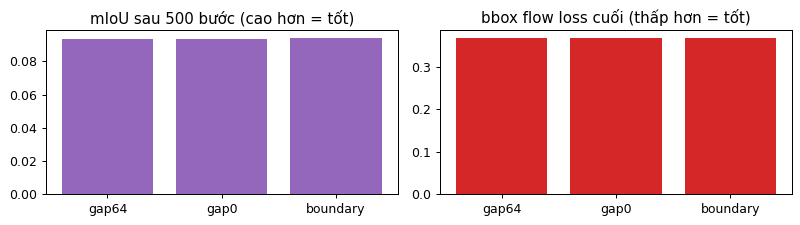

In [16]:
# ===== Cell 16: gap ablation =====
from dataclasses import replace
abl_results = {}
for name, kw in {'gap64': dict(ar_dm_gap=64.0, use_boundary_embedding=False),
                 'gap0': dict(ar_dm_gap=0.0, use_boundary_embedding=False),
                 'boundary': dict(ar_dm_gap=0.0, use_boundary_embedding=True)}.items():
    torch.manual_seed(SEED)
    cfg_a = replace(cfg, **kw)
    m_a = JWM(cfg_a)
    print(f'--- ablation {name} ---')
    h = train_stage(m_a, ae, splits['pretrain'], cfg_a, DEV, steps=500, lr=3e-4,
                    batch_size=48, warmup=50, mode_probs={'ground': 1.0},
                    seed=SEED, log_every=250)
    g = eval_ground(m_a, ae, splits['val'], cfg_a, DEV, n=120, steps=8)
    abl_results[name] = {'miou': g['miou'], 'iou05': g['iou_at_05'],
                         'final_flow': float(np.mean([m['bbox_flow'] for m in h['metrics'][-50:]]))}
    del m_a; torch.cuda.empty_cache()
print(json.dumps(abl_results, indent=1))
fig, axes = plt.subplots(1, 2, figsize=(9, 2.6))
names = list(abl_results)
axes[0].bar(names, [abl_results[n]['miou'] for n in names], color='tab:purple')
axes[0].set_title('mIoU sau 500 bước (cao hơn = tốt)')
axes[1].bar(names, [abl_results[n]['final_flow'] for n in names], color='tab:red')
axes[1].set_title('bbox flow loss cuối (thấp hơn = tốt)')
plt.tight_layout(); plt.show()

## §10 — Latency (batch=1, kiểu robotics) + §11 — Test set + lưu checkpoint

In [17]:
# ===== Cell 17: latency =====
lat = measure_latency(model, ae, splits['val'], cfg, DEV, reps=15)

  latency qa_answer: 164.1 ms
  latency ground_50step: 821.6 ms
  latency ground_4step: 95.4 ms
  latency fd_50step: 819.0 ms
  latency fd_4step: 79.5 ms


In [18]:
# ===== Cell 18: FINAL TEST metrics + save =====
print('=== ĐÁNH GIÁ CUỐI TRÊN TEST SET (chưa từng thấy, nền từ frame thật khác) ===')
qa_t = eval_qa(model, splits['test'], cfg, DEV, n=250)
gr_t = eval_ground(model, ae, splits['test'], cfg, DEV, n=250, steps=50)
gr_t4 = eval_ground(model, ae, splits['test'], cfg, DEV, n=250, steps=4)
fd_t = eval_fd(model, ae, splits['test'], cfg, DEV, n=48, k=4, steps=50)

CKPT_DIR = os.path.join(ROOT, 'jwm', 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)
metrics = {
    'val':  {'qa_acc': qa_val['acc'], 'qa_per_kind': qa_val['per_kind'],
             'iou_at_05': gr_50['iou_at_05'], 'miou': gr_50['miou'], 'ece': gr_50['ece'],
             'iou_at_05_4step': gr_4['iou_at_05'],
             'fd_psnr': fd_val['fd_psnr_min_over_k'], 'fd_copy': fd_val['fd_psnr_copy_baseline']},
    'test': {'qa_acc': qa_t['acc'], 'qa_per_kind': qa_t['per_kind'],
             'iou_at_05': gr_t['iou_at_05'], 'miou': gr_t['miou'], 'ece': gr_t['ece'],
             'iou_at_05_4step': gr_t4['iou_at_05'],
             'fd_psnr': fd_t['fd_psnr_min_over_k'], 'fd_copy': fd_t['fd_psnr_copy_baseline'],
             'fd_beats_copy': fd_t['beats_copy_frac']},
    'ablation_gap': abl_results,
    'latency_ms': lat,
    'params_M': model.num_params() / 1e6,
    'train': {'pretrain_steps': 3000, 'sft_steps': 800, 'seed': SEED},
}
torch.save({'model': model.state_dict(), 'ae': ae.state_dict(), 'cfg': cfg.__dict__,
            'camera': cam.to_dict(), 'metrics': metrics},
           os.path.join(CKPT_DIR, 'jwm_v1.pt'))
json.dump(metrics, open(os.path.join(CKPT_DIR, 'metrics_v1.json'), 'w'),
          ensure_ascii=False, indent=1)
print('\n=== BẢNG TỔNG KẾT ===')
print(json.dumps(metrics['test'], ensure_ascii=False, indent=1))
print(f"\nĐã lưu: jwm/checkpoints/jwm_v1.pt + metrics_v1.json")
print(f'Tổng thời gian notebook: {(time.time()-T_START)/60:.1f} phút')

=== ĐÁNH GIÁ CUỐI TRÊN TEST SET (chưa từng thấy, nền từ frame thật khác) ===
  QA exact-match: 0.536 on 250 | per-kind: what_held=0.57 where=0.55 what=0.12 count=0.81 exist=0.64
  GROUND[50 steps]: IoU@0.5=0.172 mIoU=0.173 ECE=0.156 (n=250)
  GROUND[4 steps]: IoU@0.5=0.164 mIoU=0.177 ECE=0.169 (n=250)
  FD[k=4]: PSNR(best-of-4)=20.40dB vs copy-baseline=21.39dB | beats copy on 27% of pairs (n=48)

=== BẢNG TỔNG KẾT ===
{
 "qa_acc": 0.536,
 "qa_per_kind": {
  "what_held": 0.5698924731182796,
  "where": 0.5531914893617021,
  "what": 0.125,
  "count": 0.8064516129032258,
  "exist": 0.6410256410256411
 },
 "iou_at_05": 0.1720000058412552,
 "miou": 0.17349283397197723,
 "ece": 0.15561753511428833,
 "iou_at_05_4step": 0.164000004529953,
 "fd_psnr": 20.396728515625,
 "fd_copy": 21.385658264160156,
 "fd_beats_copy": 0.2708333432674408
}

Đã lưu: jwm/checkpoints/jwm_v1.pt + metrics_v1.json
Tổng thời gian notebook: 55.7 phút


## Kết luận
Checkpoint `jwm/checkpoints/jwm_v1.pt` là **bộ não world-model** sẵn sàng gắn vào JARVIS qua
`core/world_brain.py`: trả lời câu hỏi (QA), chỉ vùng ảnh với confidence đã hiệu chuẩn (GROUND),
và mô phỏng tương lai của cảnh (FD). Bước tiếp theo: chạy trial harness với log đầy đủ
(audio, transcript, frame, predicted region, answer, confidence, latency, ground truth, failure category).

Stage 2.5: 2400 bước pretrain-mix ground-heavy + 600 bước SFT ground-heavy
  [    0/2400] mode=ground loss=2.5500 bbox_flow=0.2538 conf_bce=0.2420 iou_1step=0.2548 | 2.0 it/s
  [  200/2400] mode=ground loss=2.7453 bbox_flow=0.2734 conf_bce=0.2270 iou_1step=0.1658 | 2.1 it/s
  [  400/2400] mode=ground loss=1.4680 bbox_flow=0.1439 conf_bce=0.5804 iou_1step=0.3594 | 2.0 it/s
  [  600/2400] mode=fd     loss=0.3576 fd_flow=0.3576 | 2.0 it/s
  [  800/2400] mode=ground loss=1.2441 bbox_flow=0.1222 conf_bce=0.4346 iou_1step=0.3393 | 2.0 it/s
  [ 1000/2400] mode=qa     loss=0.4588 qa_ce=0.4588 qa_tok_acc=0.9540 | 1.9 it/s
  [ 1200/2400] mode=fd     loss=0.3505 fd_flow=0.3505 | 2.0 it/s
  [ 1400/2400] mode=qa     loss=0.3774 qa_ce=0.3774 qa_tok_acc=0.9627 | 1.9 it/s
  [ 1600/2400] mode=ground loss=0.4392 bbox_flow=0.0415 conf_bce=0.4915 iou_1step=0.4752 | 1.9 it/s
  [ 1800/2400] mode=fd     loss=0.3272 fd_flow=0.3272 | 1.9 it/s
  [ 2000/2400] mode=ground loss=0.4819 bbox_flow=0.0453 conf_bce=0.5

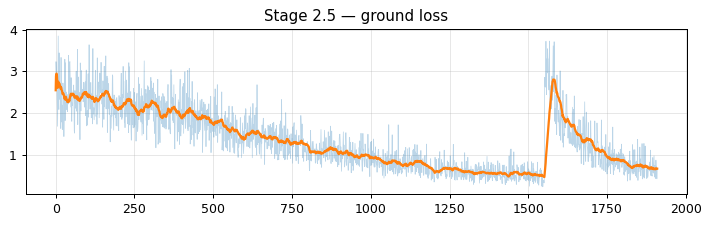

In [19]:
# ===== Cell 19 (Stage 2.5): extended grounding training =====
# Chẩn đoán từ v1: grounding underfit (IoU@0.5=0.17; ground mode chỉ ~1400/3800 bước).
# Train tiếp cùng model trong RAM, trộn thiên về GROUND, giữ QA/FD để không quên.
print('Stage 2.5: 2400 bước pretrain-mix ground-heavy + 600 bước SFT ground-heavy')
hist3 = train_stage(model, ae, splits['pretrain'], cfg, DEV, steps=2400, lr=1.5e-4,
                    batch_size=48, warmup=100,
                    mode_probs={'qa': 0.2, 'ground': 0.65, 'fd': 0.15},
                    seed=SEED + 2, log_every=200)
hist3b = train_stage(model, ae, splits['sft'], cfg, DEV, steps=600, lr=5e-5,
                     batch_size=48, warmup=50,
                     mode_probs={'qa': 0.25, 'ground': 0.6, 'fd': 0.15},
                     seed=SEED + 3, log_every=200)
fig, ax = plt.subplots(figsize=(8, 2.6))
gl = [l for l, m in zip(hist3['loss'] + hist3b['loss'], hist3['mode'] + hist3b['mode']) if m == 'ground']
ax.plot(gl, alpha=0.3, lw=0.6); ax.plot(rolling(gl), lw=1.8)
ax.set_title('Stage 2.5 — ground loss'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [21]:
# ===== Cell 20: re-eval + save v2 (ghi đè jwm_v1.pt cho world_brain) =====
print('=== RE-EVAL sau Stage 2.5 ===')
qa_v2 = eval_qa(model, splits['val'], cfg, DEV, n=250)
gr_v2 = eval_ground(model, ae, splits['val'], cfg, DEV, n=250, steps=50)
gr_v2_4 = eval_ground(model, ae, splits['val'], cfg, DEV, n=250, steps=4)
fd_v2 = eval_fd(model, ae, splits['val'], cfg, DEV, n=48, k=4, steps=50)
print('--- test ---')
qa_t2 = eval_qa(model, splits['test'], cfg, DEV, n=250)
gr_t2 = eval_ground(model, ae, splits['test'], cfg, DEV, n=250, steps=50)
gr_t2_4 = eval_ground(model, ae, splits['test'], cfg, DEV, n=250, steps=4)
fd_t2 = eval_fd(model, ae, splits['test'], cfg, DEV, n=48, k=4, steps=50)
metrics['v2_after_stage25'] = {
 'val': {'qa_acc': qa_v2['acc'], 'iou_at_05': gr_v2['iou_at_05'], 'miou': gr_v2['miou'],
         'ece': gr_v2['ece'], 'iou_at_05_4step': gr_v2_4['iou_at_05'],
         'fd_psnr': fd_v2['fd_psnr_min_over_k'], 'fd_copy': fd_v2['fd_psnr_copy_baseline']},
 'test': {'qa_acc': qa_t2['acc'], 'qa_per_kind': qa_t2['per_kind'],
          'iou_at_05': gr_t2['iou_at_05'], 'miou': gr_t2['miou'], 'ece': gr_t2['ece'],
          'iou_at_05_4step': gr_t2_4['iou_at_05'],
          'fd_psnr': fd_t2['fd_psnr_min_over_k'], 'fd_copy': fd_t2['fd_psnr_copy_baseline'],
          'fd_beats_copy': fd_t2['beats_copy_frac']},
 'train_extra': {'steps': 3000, 'mode_probs': 'ground-heavy 0.65/0.6'}}
torch.save({'model': model.state_dict(), 'ae': ae.state_dict(), 'cfg': cfg.__dict__,
            'camera': cam.to_dict(), 'metrics': metrics},
           os.path.join(CKPT_DIR, 'jwm_v1.pt'))
json.dump(metrics, open(os.path.join(CKPT_DIR, 'metrics_v1.json'), 'w'), ensure_ascii=False, indent=1)
print(json.dumps(metrics['v2_after_stage25']['test'], ensure_ascii=False, indent=1))
print('Saved jwm_v1.pt (v2 weights) + metrics_v1.json')

=== RE-EVAL sau Stage 2.5 ===
  QA exact-match: 0.572 on 250 | per-kind: what_held=0.60 what=0.29 where=0.63 exist=0.69 count=0.70
  GROUND[50 steps]: IoU@0.5=0.156 mIoU=0.175 ECE=0.427 (n=250)
  GROUND[4 steps]: IoU@0.5=0.160 mIoU=0.170 ECE=0.409 (n=250)
  FD[k=4]: PSNR(best-of-4)=20.32dB vs copy-baseline=22.05dB | beats copy on 6% of pairs (n=48)
--- test ---
  QA exact-match: 0.564 on 250 | per-kind: what_held=0.58 where=0.60 what=0.23 count=0.77 exist=0.67
  GROUND[50 steps]: IoU@0.5=0.164 mIoU=0.201 ECE=0.428 (n=250)
  GROUND[4 steps]: IoU@0.5=0.184 mIoU=0.192 ECE=0.402 (n=250)
  FD[k=4]: PSNR(best-of-4)=20.10dB vs copy-baseline=21.39dB | beats copy on 31% of pairs (n=48)
{
 "qa_acc": 0.564,
 "qa_per_kind": {
  "what_held": 0.5806451612903226,
  "where": 0.5957446808510638,
  "what": 0.225,
  "count": 0.7741935483870968,
  "exist": 0.6666666666666666
 },
 "iou_at_05": 0.164000004529953,
 "miou": 0.20144668221473694,
 "ece": 0.4280106723308563,
 "iou_at_05_4step": 0.184000000357627